# 001b Friedel pairs Batch

Written by Jean-Baptiste Jacob

Last updated: 18/02/2026

Run find_friedel_pairs.py to match friedel pairs for a series of datasets. Use parallelization for faster computation. Parameters for friedel pair search are edited directly in the script file (find_friedel_pairs.py)

In [3]:
import sys

# python environment stuff
IMAGED11_PATH = '/home/esrf/jean1994b/ImageD11_jbjacob'  # None means do not use git, otherwise enter the name of the folder to use for the git checkout "ImageD11" or "ImageD11_version_xx", etc
CHECKOUT_PATH = 'ImageD11'  # the name of the git checkout folder within path. None means guess

if IMAGED11_PATH is not None:
    if '/data/id11/nanoscope' not in sys.path:
        sys.path.append('/data/id11/nanoscope')
    import install_ImageD11_from_git
    PYTHONPATH = install_ImageD11_from_git.setup_ImageD11_from_git(IMAGED11_PATH,CHECKOUT_PATH)
else:
    import site
    PYTHONPATH = site.getsitepackages()[0]
    print(PYTHONPATH)

# Setting path via: 
sys.path.insert(0, /home/esrf/jean1994b/ImageD11 )
# Running from: /home/esrf/jean1994b/ImageD11/ImageD11/__init__.py


In [4]:
# General modules
import os
import h5py
import matplotlib.pyplot as pl
import numpy as np

# ImageD11: https://github.com/FABLE-3DXRD/ImageD11
import ImageD11.sinograms.dataset
ImageD11.sparseframe, ImageD11.blobcorrector, ImageD11.columnfile

# pf_3dxrd: Friedel Pair scanning 3DXRD module
# Available at: https://github.com/jbjacob94/pf_3dxrd
# Not yet installable with pip; copy the files into your working folder. Do not forget to add the folder in your sys.path if it is not the case already: sys.path.append('my_path')
from pf3dxrd.pf3dxrd import utils, friedel_pairs, crystal_structure
from pf3dxrd.scripts import find_friedel_pairs

%matplotlib ipympl
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Build commands

In [12]:
# paths
data_dir = '/home/esrf/jean1994b/test_datasets/SI3/'                           # folder containing your data
#data_dir = '/home/esrf/jean1994b/test_datasets/C18A_01_z180/'
data_dir = '/home/esrf/jean1994b/BREAK_Apr23/BER69/BER69_3000um/'

parfile  = data_dir+'SI3.par'                                                  # parameter file
#parfile = data_dir+'C18A_01.par'
parfile = '/home/esrf/jean1994b/BREAK_Apr23/quartz_Nscope.par'

splinefile = data_dir+'/frelon21_mar16.spline'                                 # spline file for detector distortion (frelon)

# list of datasets to process. Only one in example, but aimed to work with n >= 1
dset_list = ['SI3_DT360Z5480']                                                 
#dset_list = ['C18A_01_z180']
dset_list = ['BER69_3000um']

In [13]:
# functions to get path names from dataset name
def get_pkspath(dsname):
    return os.path.join(data_dir, dsname+'_pk2d.h5')     # extension name '*pk2d.h5' may need to be updated if working with peaks table

def get_dspath(dsname):
    return os.path.join(data_dir, dsname+'_dataset.h5')

In [14]:
# have a look at options in find_friedel_pairs.py and update them if needed. Do not forget to save in an option file (json)
OPTS = find_friedel_pairs.Options()
print(OPTS)

dist_max: 1.5
dist_step: 0.1
sf_tth: 1.0
sf_I: 1.0
Npx_min: 3
sumI_min: 30
sumI_max: 10000000.0
tth_max: 30
max_tth_dist: 1.0
max_eta_dist: 1.0
max_omega_dist: 1.0
max_logI_dist: 1.0
ncpu: 39
chunksize: 4


In [5]:
# SI3
OPTS.dist_max = 1.
OPTS.sf_tth = 1/5
OPTS.sf_I = 1/5
OPTS.sumI_min = 30
OPTS.tth_max = 13.5
OPTS.max_eta_dist  = 0.5
OPTS.max_omega_dist = 0.5
OPTS.max_tth_dist = 0.8
OPTS.max_logI_dist = 0.8
OPTS.chunksize = 3

In [88]:
#C18A_01
OPTS.dist_max = .7
OPTS.dist_step = 0.1
OPTS.sf_tth = 2
OPTS.sf_I = 1
OPTS.sumI_min = 10
OPTS.tth_max = 28.5
OPTS.max_eta_dist  = 0.2
OPTS.max_omega_dist = 0.08
OPTS.max_tth_dist = .8
OPTS.max_logI_dist = 0.5
OPTS.chunksize = 2

In [15]:
OPTS.dist_max = 1.5
OPTS.sf_tth = 1/5
OPTS.sf_I = 1/5
OPTS.sumI_min = 10
OPTS.tth_max = 28.5
OPTS.max_eta_dist  = 0.5
OPTS.max_omega_dist = 0.5
OPTS.max_tth_dist = 0.8
OPTS.max_logI_dist = 0.8
OPTS.chunksize = 3

In [16]:
opts_file = os.path.join(data_dir,f"friedel_pairs_opts.json")
OPTS.save(opts_file)

[SAVED] Options saved to /home/esrf/jean1994b/BREAK_Apr23/BER69/BER69_3000um/friedel_pairs_opts.json


In [17]:
# prepare commands run to find_friedel_pairs.py

def get_command(dsname):
    pksfile = get_pkspath(dsname)
    dsfile = get_dspath(dsname)
    
    command = f'{find_friedel_pairs.__file__} -pksfile {pksfile} -dsfile {dsfile} -parfile {parfile} -splinefile {splinefile}'\
    f' -use2Dpeaks True -pairing_options {opts_file}'
    
    return command


jobs = [get_command(dsname) for dsname in dset_list]

jobs[0]

'/home/esrf/jean1994b/pf3dxrd/scripts/find_friedel_pairs.py -pksfile /home/esrf/jean1994b/BREAK_Apr23/BER69/BER69_3000um/BER69_3000um_pk2d.h5 -dsfile /home/esrf/jean1994b/BREAK_Apr23/BER69/BER69_3000um/BER69_3000um_dataset.h5 -parfile /home/esrf/jean1994b/BREAK_Apr23/quartz_Nscope.par -splinefile /home/esrf/jean1994b/BREAK_Apr23/BER69/BER69_3000um//frelon21_mar16.spline -use2Dpeaks True -pairing_options /home/esrf/jean1994b/BREAK_Apr23/BER69/BER69_3000um/friedel_pairs_opts.json'

### Submit jobs

In [24]:
for j in jobs:
    !python {j}



[LOG] Writing output to /home/esrf/jean1994b/BREAK_Apr23/BER69/BER69_3000um/fpairs_matching_20260526_095813.log


---------------------------------
PARAMETERS FOR FRIEDEL PAIR SEARCH:
dist_max: 1.5
dist_step: 0.1
sf_tth: 0.2
sf_I: 0.2
Npx_min: 3
sumI_min: 10
sumI_max: 10000000.0
tth_max: 28.5
max_tth_dist: 0.8
max_eta_dist: 0.5
max_omega_dist: 0.5
max_logI_dist: 0.8
ncpu: 39
chunksize: 3
use2Dpeaks True
---------------------------------
Loading data for dataset BER69_3000um: 
n_ystep: 621.00
n_ostep: 7220.00
ymin: -3100.00
ymax: 3100.00
ystep: 10.00
omin: 0.00
omax: 360.00
ostep: 0.05
loading peaks...
Reading your columnfile in hdf format
loaded peaks from peakfile
nrows = 258872926
Total size =  12837.79 MB
copied an array: size=258872926, elsize=4
copied an array: size=258872926, elsize=4
copied an array: size=258872926, elsize=4

Form pairs of dty scans and check symmetry
dty_center =  0.00  on bin n° 310
dty pairs: 
0.0000 ; 0.0000
10.0000 ; -10.0000
20.0000 ; -20.0000
30.0000 ; -

### Look at outputs

CS: quartz, phase_id: 0, spg: P3221, spg_no: 154, lattice: [  4.91921   4.91921   5.41186  90.       90.      120.     ]
CS: orthoclase, phase_id: 1, spg: C1-11, spg_no: 12, lattice: [  8.589  13.013   7.197  90.    116.02   90.   ]
CS: oligoclase, phase_id: 2, spg: C-1, spg_no: 2, lattice: [  8.154  12.823   7.139  94.06  116.5    88.59 ]
CS: biotite, phase_id: 3, spg: C12/m1, spg_no: 12, lattice: [  5.355   9.251  10.246  90.    100.15   90.   ]
CS: magnetite, phase_id: 4, spg: Fd3m, spg_no: 227, lattice: [ 8.3965  8.3965  8.3965 90.     90.     90.    ]
Scatter(quartz with 2 atomic positions, 6 symmetries)
       Type: x-ray
     Energy: 43.57356018082551 keV
 Wavelength: 0.28454050670689945 A
 ---Settings---
      Powder units: tth
    Isotropic ADPs: True
  Specular Direction (reflection): ( 0, 0, 1)
Parallel Direction (transmission): ( 0, 0, 1)
      theta offset: 0.0
         min theta: -180.0
         max theta: 180.0
      min twotheta: 0
      max twotheta: 15
 ---X-Ray Setti

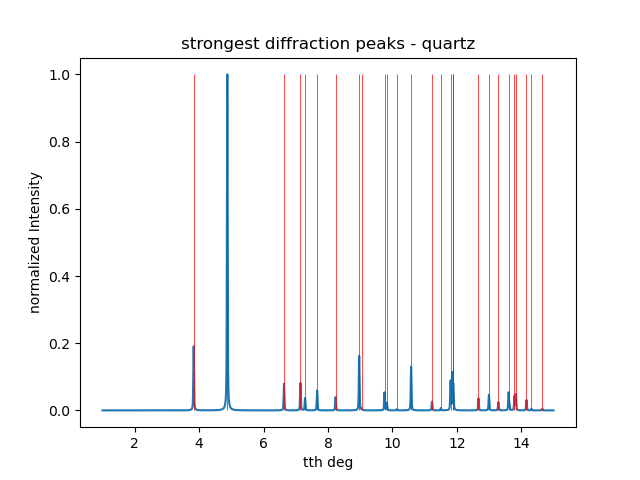

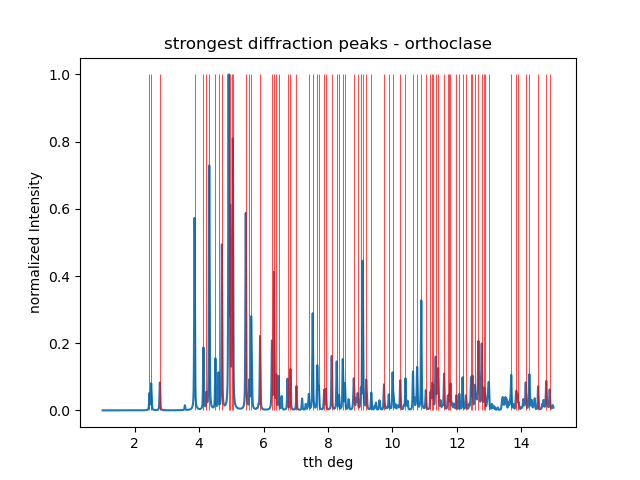

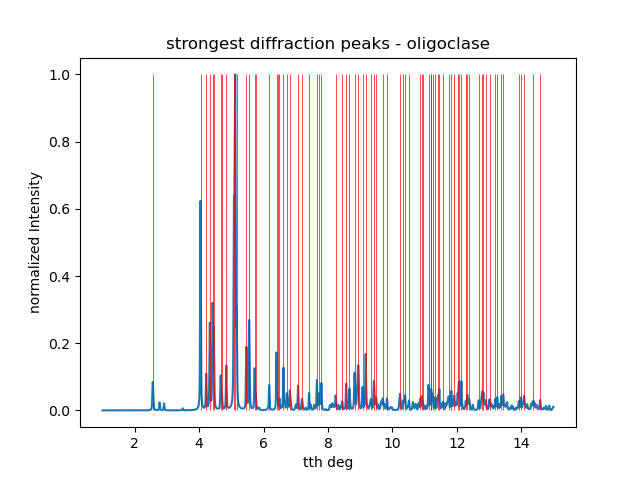

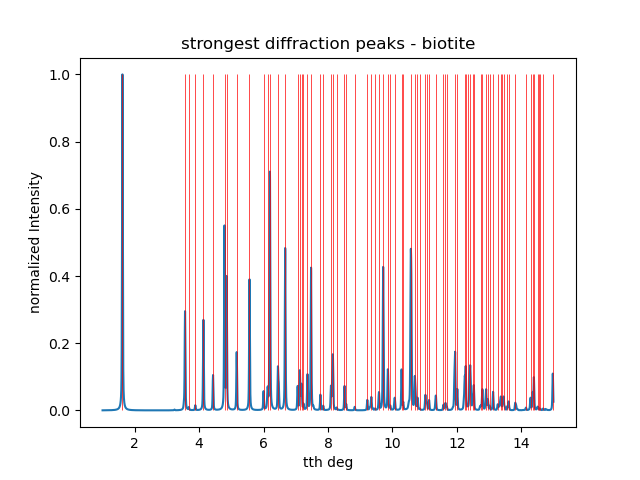

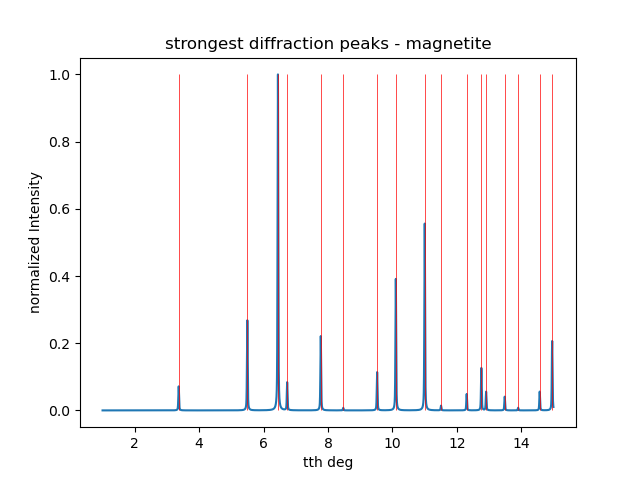

In [9]:
# define a dictionary with all  phases. Here we assume that we already know what are the phases in the sample, but it might be something we want to determine as well
phase_names = ['quartz','orthoclase','oligoclase','biotite','magnetite']
phase_dict = {}

for i,p in enumerate(phase_names):
    cs = crystal_structure.load_CS_from_cif(cif_path = f'cif/{p}.cif', name=p, pid=i)
    print(cs)
    phase_dict[p] = cs
    
pars = ImageD11.parameters.read_par_file(parfile)
wl = pars.get('wavelength')   # from parameter file

# compute theoretical 2θ rings: compute a simulated powder spectrum, and then we run a peaksearch on this spectrum to find the N-strongest peaks.
# This allows to retain only the most significant peaks, and not care about all the numerous, very low intensity peaks which theoretically exist but 
#are practically barely visible.

for cs in phase_dict.values():
    cs.compute_powder_spec(wl, min_tth=0, max_tth=15, doplot=False)
    cs.find_strongest_peaks(Imin=0.001, prominence=0.001, Nmax=80, doplot=True)

In [10]:
def load_paired_pksfile(dsname):
    pksfile = get_pkspath(dsname).replace('.h5','_p.h5')
    dsfile = get_dspath(dsname)
    
    cf = ImageD11.columnfile.columnfile(pksfile)
    ds = ImageD11.sinograms.dataset.load(dsfile)
    cf.parameters.loadparameters(parfile)
    cfp = cf.copy()
    
    friedel_pairs.update_geometry_fpairs(cfp, ds, relocate_fpairs=True)
    cf.updateGeometry()
    
    return cf, cfp, ds


def make_plots(cf, cfp, ds, **kw):
    fig = pl.figure(figsize=(10,10))
    
    fig.add_subplot(221)
    pl.hist(cf.fp_dist,100);
    pl.xlabel('fp_dist')
    
    fig.add_subplot(222)
    r = utils.friedel_recon(cfp, ds.ybinedges, ds.ybinedges, mask=None, weight_by_intensity=True, norm=True, doplot=False)
    pl.pcolormesh(ds.ybinedges, ds.ybinedges, r, **kw)
    
    fig.add_subplot(212)
    h,b,_ = utils.compute_tth_histogram(cf, tthmin=0, tthmax=15, tthstep=0.0005, density=True, uself=True)
    hc,bc,_ = utils.compute_tth_histogram(cfp, tthmin=0, tthmax=15, tthstep=0.0005, density=True, uself=True)
    
    pl.plot(b,h, ls='dotted', color='darkgrey', lw=.8, label='uncorrected tth')
    pl.plot(bc,hc,ls='-',color='dimgrey', lw=1., label ='corrected tth')
    
    for cs in phase_dict.values():
        pl.vlines(cs.strong_peaks[0], -1, 0, colors=cs.color, label = cs.name)
    pl.xlabel('tth deg')
    pl.legend()
    
    fig.suptitle(ds.dsname)

In [11]:
# reload paired peakfiles 
pksfiles = []
pksfiles_p = []
dsfiles = []

for d in dset_list:
    cf, cfp, ds = load_paired_pksfile(d)
    pksfiles.append(cf)
    pksfiles_p.append(cfp)
    dsfiles.append(ds)

Reading your columnfile in hdf format
sorting peakfile by friedel pair index...


copied an array: size=3125506, elsize=4
copied an array: size=3125506, elsize=4
copied an array: size=3125506, elsize=4
copied an array: size=3125506, elsize=4
copied an array: size=3125506, elsize=4
copied an array: size=3125506, elsize=4
copied an array: size=3125506, elsize=4


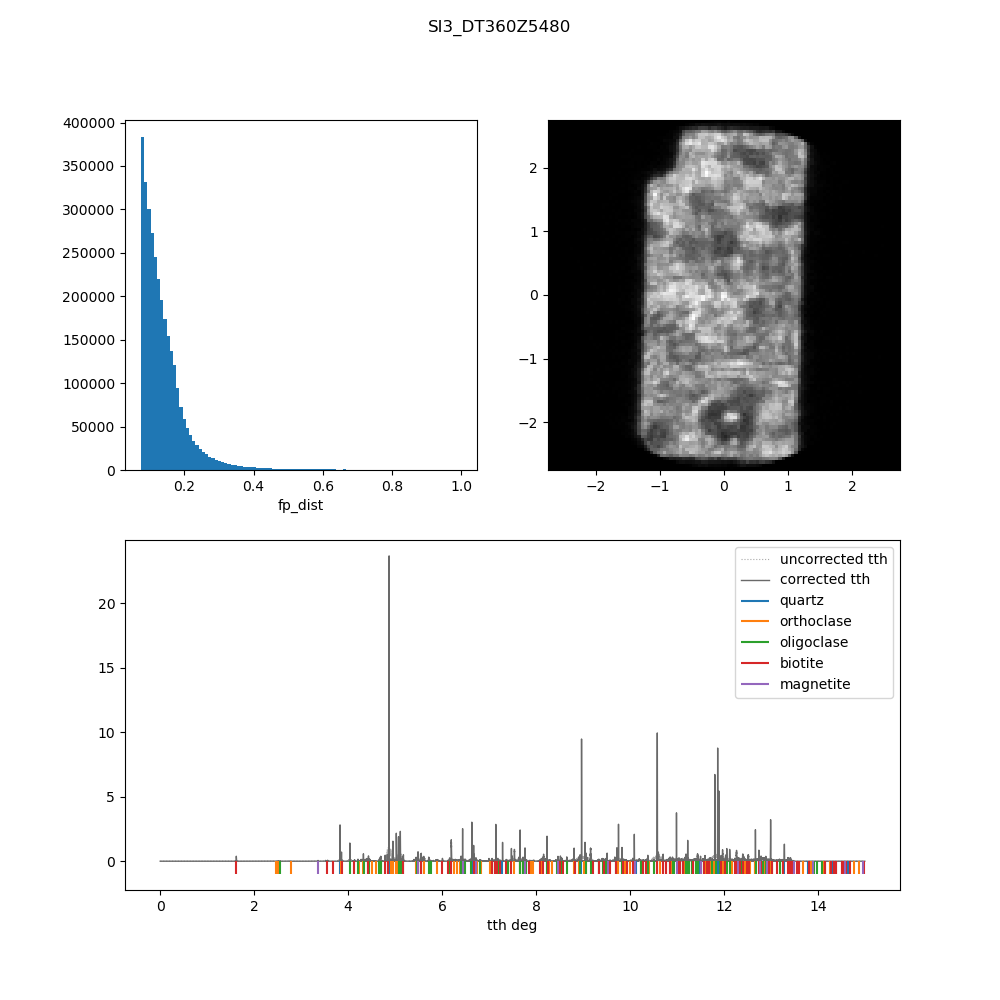

In [12]:
# make plots
kw = {'cmap': 'Greys_r', 'vmin':0, 'vmax':1}

for cf, ds in zip(pksfiles,dsfiles):
    make_plots(cf, cfp, ds,**kw)

Text(0.5, 0.98, 'SI3')

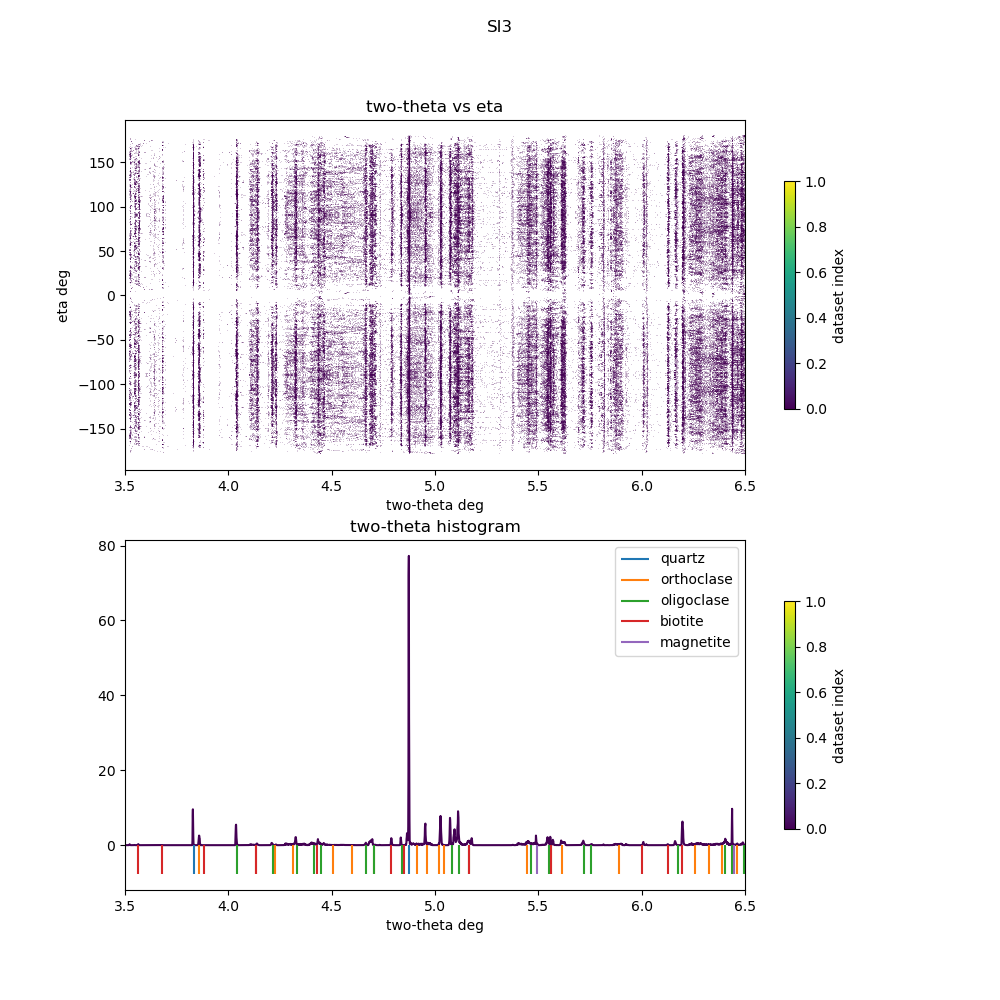

In [123]:
# stack all tth hist on one splot
pl.close('all')

# colormap to color plots by dataset index
cmap = pl.matplotlib.cm.viridis.copy()
norm=pl.matplotlib.colors.Normalize(vmin=0, vmax=len(dset_list))

sm = pl.matplotlib.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# plot
tthmin, tthmax  = 3.5,6.5
fig = pl.figure(figsize=(10,10))

ax1 = fig.add_subplot(211)
for cfp, ds in zip(pksfiles_p,dsfiles):
    dset_indx = dsfiles.index(ds)
    m = np.all([cfp.tth <= tthmax, cfp.tth>=tthmin], axis=0)
    pl.plot(cfp.tth[m],cfp.eta[m],',', color=cmap(norm(dset_indx)), alpha=.2)
    
pl.colorbar(sm, ax=ax1, label='dataset index', orientation='vertical', pad = 0.05, shrink=0.65)
pl.title('two-theta vs eta')
pl.xlabel('two-theta deg')
pl.ylabel('eta deg')
pl.xlim(tthmin,tthmax)
    
ax2 = fig.add_subplot(212)
for cfp, ds in zip(pksfiles_p,dsfiles):
    dset_indx = dsfiles.index(ds)
    h,b,_ = utils.compute_tth_histogram(cfp, tthmin=tthmin, tthmax=tthmax, tthstep=0.001, density=True, uself=True)
    pl.plot(b,h, color=cmap(norm(dset_indx)))
    
for cs in phase_dict.values():
    pl.vlines(cs.strong_peaks[0], -.1*h.max(), 0, colors=cs.color, label=cs.name)

pl.colorbar(sm, ax=ax2, label='dataset index', orientation='vertical', pad = 0.05, shrink=0.65)
pl.legend()
pl.title('two-theta histogram')
pl.xlabel('two-theta deg')
pl.xlim(tthmin,tthmax)
fig.suptitle(ds.sample)